# cheesypy tutorial

`cheesypy` is the Python client for the [Cheesemonger](https://github.com/broadinstitute/cheesemonger) perturb-seq API.
It talks to a Cheesemonger server over HTTP and returns results as **pandas** objects, so you can go from a query to a plot in one line.

This notebook walks through:
1. Connecting to a server
2. Exploring datasets & metadata
3. Every query pattern (series, multi-datatype, aggregation, count, cross-screen, multi-screen, diagonal)
4. Plotting (a volcano plot)

> Run order matters only for the connection cell; the query cells are independent.

In [16]:
!uv pip install cheesypy --extra-index-url https://us-central1-python.pkg.dev/cds-artifacts/public-python/simple/

Using Python 3.12.13 environment at: /Users/naquib/GitHub/cheesemonger/.venv
Checked 1 package in 7ms


In [17]:
!uv pip install cheesypy --upgrade-package cheesypy --reinstall-package cheesypy --refresh-package cheesypy \
  --extra-index-url https://us-central1-python.pkg.dev/cds-artifacts/public-python/simple/

Using Python 3.12.13 environment at: /Users/naquib/GitHub/cheesemonger/.venv
Resolved 12 packages in 1.78s                                        
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)                          ....
⠙ Preparing packages... (0/1)                          ....
⠙ Preparing packages... (0/1)                          ....
⠙ Preparing packages... (0/1)                          ....
Prepared 1 package in 110ms                                                  
Uninstalled 1 package in 0.78ms
Installed 1 package in 1ms                                  
 ~ cheesypy==0.1.0


In [3]:
!uv pip install matplotlib

Using Python 3.12.13 environment at: /Users/naquib/GitHub/cheesemonger/.venv
Checked 1 package in 5ms


In [10]:
import httpx

from cheesypy import Cheesemonger

DEV_BASE_URL = "https://dev.cds.team/cheesemonger"
PROD_BASE_URL = "https://cheesemonger.cds.team/"


cm_dev = Cheesemonger(DEV_BASE_URL, _client=httpx.Client(base_url=DEV_BASE_URL, auth=("cheesemonger-test", "crackers1020"), timeout=600), gene_symbols=True)
cm_prod = Cheesemonger(PROD_BASE_URL, _client=httpx.Client(base_url=PROD_BASE_URL, auth=("cheesemonger-test", "crackers1020"), timeout=600), gene_symbols=True)


## 2. Explore

`list_datasets()` and `metadata()` tell you what's available — dimensions, their labels, the loaded blocks (screens), and the datatypes.

In [11]:
print(cm_dev.list_datasets())   # -> DataFrame: name, blocks, datatypes
print(cm_prod.list_datasets())   # -> DataFrame: name, blocks, datatypes

            name  blocks  datatypes
0  perturb-scuba       1         14
                 name  blocks  datatypes
0           degs-dmc3       1         15
1    ps100_correlates      16          3
2          ps100_degs      16         15
3  ps100_response_agg      16          8
4    ps100_target_agg      16          9
5    response-agg-dmc       1          8
6      target-agg-dmc       1          9
7    target-corr-dmc3       1          3


In [12]:
mapping = cm_prod.gene_mappings()
print(f"Loaded {mapping['entries_count']} gene mappings from: {mapping['taiga_id']}")
print(f"Sample entries: {dict(list(mapping['entries'].items())[:5])}")
# Output: {'1': 'A1BG', '503538': 'A1BG-AS1', '7157': 'TP53', ...}

Loaded 43849 gene mappings from: hgnc-gene-table-e250.4/hgnc_complete_set
Sample entries: {'1': 'A1BG', '503538': 'A1BG-AS1', '29974': 'A1CF', '2': 'A2M', '144571': 'A2M-AS1'}


In [13]:
cm_prod.metadata("degs-dmc3")["dimensions"]

[{'name': 'Timepoint',
  'size': 2,
  'labels': ['D4', 'D7'],
  'labels_truncated': False,
  'labels_sample': None},
 {'name': 'Target',
  'size': 10,
  'labels': ['11196',
   '23293',
   '2475',
   '4193',
   '4609',
   '51124',
   '53918',
   '5682',
   '7037',
   '7295'],
  'labels_truncated': False,
  'labels_sample': None},
 {'name': 'Response',
  'size': 13922,
  'labels': None,
  'labels_truncated': True,
  'labels_sample': ['10', '100', '10000', '10001', '10003']}]

In [15]:
cm_prod.dimension_labels("degs-dmc3", "Target") # every target/full list

AttributeError: 'Cheesemonger' object has no attribute 'dimension_labels'

In [45]:
meta = cm_dev.metadata("perturb-scuba")
print("last_dimension:", meta["last_dimension"])
print("dimensions:", [(d["name"], d["size"]) for d in meta["dimensions"]])
print("blocks:", [b["name"] for b in meta["blocks"]])
print("datatypes:", [d["name"] for d in meta["datatypes"]])

last_dimension: screen
dimensions: [('Timepoint', 2), ('Response', 14588), ('Target', 2)]
blocks: ['PS-SC-1']
datatypes: ['CtrlPseudobulk', 'TargetPseudobulk', 'DetrendedMeanDifference', 'nTargetCells', 'STD', 'nPermutations', 'ZScore', 'L2FC', 'nCtrlCells', 'PermutationP', 'FDR', 'MeanDifference', 'nNonzeroCtrlCells', 'nNonzeroTargetCells']


## 3. Concepts in one line

A query **fixes** some dimensions (as keyword args) and returns the ones left free.

- The **block key** (here `screen`) selects one screen; include it to target a block, omit it to span all blocks.
- Fix all but one dimension → a vector (`Series`); fix all → a scalar.
- The PESCA dims are `Timepoint` (e.g. `"D4"`, `"D7"`), `Target` (perturbed gene, entrez ID), `Response` (measured gene, entrez ID).

## 4. Series query — one perturbation, all response genes

Fix screen + timepoint + target; get the ZScore across every response gene. Returns a `pd.Series` indexed by `Response`.

In [40]:
%%time
cm.series("perturb-scuba", "ZScore", screen="PS-SC-1", Timepoint="D4", Target="23293")

CPU times: user 15.3 ms, sys: 3.92 ms, total: 19.2 ms
Wall time: 406 ms


Response
NAT2       -0.634196
ADA        -0.919917
AKT3       -2.592765
MED6       -0.141573
NR2E3            NaN
              ...   
PTBP3       1.267076
KCNE2            NaN
DGCR2       0.711425
CASP8AP2   -0.041512
SCO2        1.351179
Name: ZScore, Length: 14588, dtype: float64

In [28]:
%%time
cm.series("perturb-scuba", "ZScore", screen="PS-SC-1", Timepoint="D4", Target="23293")

CPU times: user 27.2 ms, sys: 5.68 ms, total: 32.9 ms
Wall time: 866 ms


Response
NAT2       -0.634196
ADA        -0.919917
AKT3       -2.592765
MED6       -0.141573
NR2E3            NaN
              ...   
PTBP3       1.267076
KCNE2            NaN
DGCR2       0.711425
CASP8AP2   -0.041512
SCO2        1.351179
Name: ZScore, Length: 14588, dtype: float64

In [29]:
%%time

df = cm. series("perturb-scuba", ["L2FC", "FDR", "ZScore"], screen="PS-SC-1", Timepoint="D4", Target="23293")
df. head()

CPU times: user 22.7 ms, sys: 5.05 ms, total: 27.7 ms
Wall time: 911 ms


datatype,L2FC,FDR,ZScore
Response,,,
NAT2,-0.004180,0.817551,-0.634196
ADA,-0.063886,0.737323,-0.919917
AKT3,-0.103139,0.137135,-2.592765
MED6,-0.003405,0.934139,-0.141573
NR2E3,NaN,NaN,NaN


In [30]:
%%time
z = cm.series("perturb-scuba", "ZScore",
              screen="PS-SC-1", Timepoint="D4", Target="23293")
print(type(z), z.shape, "| index:", z.index.name)
z.head()

<class 'pandas.Series'> (14588,) | index: Response
CPU times: user 14.4 ms, sys: 3.82 ms, total: 18.2 ms
Wall time: 340 ms


Response
NAT2    -0.634196
ADA     -0.919917
AKT3    -2.592765
MED6    -0.141573
NR2E3         NaN
Name: ZScore, dtype: float64

## 5. Several datatypes at once (volcano data)

Pass a list of datatypes at the same coordinates → a `pd.DataFrame` (rows = response genes, columns = datatypes). This is the one-call way to get everything a volcano plot needs.

In [31]:
%%time
df = cm.series("perturb-scuba", ["L2FC", "FDR", "ZScore"],
               screen="PS-SC-1", Timepoint="D4", Target="23293")
df.head()

CPU times: user 22.4 ms, sys: 4.84 ms, total: 27.2 ms
Wall time: 432 ms


datatype,L2FC,FDR,ZScore
Response,,,
NAT2,-0.004180,0.817551,-0.634196
ADA,-0.063886,0.737323,-0.919917
AKT3,-0.103139,0.137135,-2.592765
MED6,-0.003405,0.934139,-0.141573
NR2E3,NaN,NaN,NaN


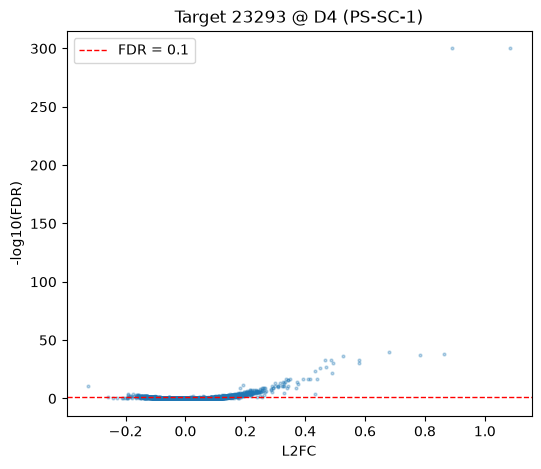

CPU times: user 52.2 ms, sys: 9.93 ms, total: 62.1 ms
Wall time: 72.5 ms


In [32]:
%%time
import matplotlib.pyplot as plt
import numpy as np

df = df.dropna(subset=["L2FC", "FDR"])
y = -np.log10(df["FDR"].clip(lower=1e-300))

plt.figure(figsize=(6, 5))
plt.scatter(df["L2FC"], y, s=4, alpha=0.3)
plt.axhline(-np.log10(0.1), color="red", ls="--", lw=1, label="FDR = 0.1")
plt.xlabel("L2FC"); plt.ylabel("-log10(FDR)")
plt.title("Target 23293 @ D4 (PS-SC-1)"); plt.legend(); plt.show()

## 6. Aggregation within a screen

Collapse a dimension with `aggregate(...)`. `how="mean"` over `Target` gives the mean ZScore across all targets, one value per response gene.

In [33]:
%%time
mean_z = cm.aggregate("perturb-scuba", "ZScore",
                      over="Target", how="mean",
                      screen="PS-SC-1", Timepoint="D4")
print(mean_z.shape, "| index:", mean_z.index.name)
mean_z.head()

(14588,) | index: Response
CPU times: user 15.6 ms, sys: 3.53 ms, total: 19.1 ms
Wall time: 464 ms


Response
NAT2    -0.621085
ADA     -0.744326
AKT3    -1.443740
MED6    -0.355154
NR2E3         NaN
Name: ZScore, dtype: float64

## 7. Count significant hits

`how="count_lt"` counts values below a threshold. Counting `FDR < 0.1` over `Response` gives, per target, how many response genes were significant.

In [34]:
%%time
hits = cm.aggregate("perturb-scuba", "FDR",
                    over="Response", how="count_lt", threshold=0.1,
                    screen="PS-SC-1", Timepoint="D4")
hits   # Series indexed by Target

CPU times: user 1.73 ms, sys: 1.07 ms, total: 2.8 ms
Wall time: 224 ms


Target
SMG6     718
MTPAP     12
Name: FDR, dtype: int64

## 7b. More Aggreagations

`aggregate(...)` supports more than `mean` and `count_lt`. Every kind reduces the `over` dimension:

| `how` | result | `threshold` |
|-------|--------|-------------|
| `mean`, `median`, `min`, `max` | that statistic (NaN-ignoring) | — |
| `count` | number of non-NaN (tested) values | — |
| `count_lt` / `count_gt` | count of values `<` / `>` the threshold | required |
| `abs_gt` | count of values with `abs(value) > threshold` (large effects, either direction) | required |

The examples below reduce over `Response`, so each returns one value per `Target`. Any of them also work cross-screen with `over="screen"` (see §8).

In [35]:
%%time
# Threshold counts: large up-regulated effects (L2FC > 1), and large effects in
# either direction (|L2FC| > 1), per target at D4.

import pandas as pd

up  = cm.aggregate("perturb-scuba", "L2FC", over="Response", how="count_gt", threshold=1.0,
                   screen="PS-SC-1", Timepoint="D4")
big = cm.aggregate("perturb-scuba", "L2FC", over="Response", how="abs_gt", threshold=1.0,
                   screen="PS-SC-1", Timepoint="D4")
pd.DataFrame({"up (L2FC > 1)": up, "large (|L2FC| > 1)": big})   # rows = Target

CPU times: user 4.54 ms, sys: 2.02 ms, total: 6.56 ms
Wall time: 344 ms


,up (L2FC > 1),large (|L2FC| > 1)
Target,,
SMG6,1,1
MTPAP,0,0


In [36]:
%%time
# min / max / median of L2FC across response genes, per target
import pandas as pd

mn  = cm.aggregate("perturb-scuba", "L2FC", over="Response", how="min",    screen="PS-SC-1", Timepoint="D4")
med = cm.aggregate("perturb-scuba", "L2FC", over="Response", how="median", screen="PS-SC-1", Timepoint="D4")
mx  = cm.aggregate("perturb-scuba", "L2FC", over="Response", how="max",    screen="PS-SC-1", Timepoint="D4")
pd.DataFrame({"min": mn, "median": med, "max": mx})   # rows = Target

CPU times: user 6.93 ms, sys: 1.51 ms, total: 8.44 ms
Wall time: 574 ms


,min,median,max
Target,,,
SMG6,-0.326335,0.003715,1.085704
MTPAP,-0.940467,0.001348,0.642235


In [37]:
%%time
# `count`: how many response genes were actually tested (non-NaN) per target
tested = cm.aggregate("perturb-scuba", "FDR", over="Response", how="count",
                      screen="PS-SC-1", Timepoint="D4")
tested   # Series indexed by Target

CPU times: user 1.88 ms, sys: 1.8 ms, total: 3.68 ms
Wall time: 150 ms


Target
SMG6     12930
MTPAP    12915
Name: FDR, dtype: int64

## 8. Across screens

Two cross-screen patterns (these need **more than one** screen loaded):

- **Aggregate over screen** — collapse the screens into one vector (`over="screen"`).
- **Span screens without aggregating** — omit the block key; get a `DataFrame` (screen × response gene) to compare them side by side.

In [38]:
# Mean ZScore across all screens for one target at D4 (one value per response gene)
across = cm.aggregate("perturb-scuba", "ZScore",
                      over="screen", how="mean",
                      Timepoint="D4", Target="23293")
across.head()

Response
NAT2    -0.634196
ADA     -0.919917
AKT3    -2.592765
MED6    -0.141573
NR2E3         NaN
Name: ZScore, dtype: float64

In [42]:
# Compare the same vector across screens (omit `screen`). With >1 screen this is a DataFrame.
per_screen = cm.series("perturb-scuba", "ZScore", Timepoint="D4", Target="23293")
per_screen.head()

Response
NAT2    -0.634196
ADA     -0.919917
AKT3    -2.592765
MED6    -0.141573
NR2E3         NaN
Name: ZScore, dtype: float64

## 9. Diagonal (self-targeting)

The diagonal pulls values where two dimensions share a coordinate label — e.g. the response of a gene to *its own* knockout. Returns a `Series` indexed by the shared label.

In [43]:
self_effect = cm.diagonal("perturb-scuba", "L2FC",
                          dims=("Target", "Response"),
                          screen="PS-SC-1", Timepoint="D4")
self_effect

label
SMG6    -0.326335
MTPAP   -0.320831
Name: L2FC, dtype: float64

## 10. Raw responses & full control

Pass `raw=True` to any read to get the plain response dict instead of pandas. Or use the low-level `query(...)`, which mirrors the API exactly.

In [17]:
raw = cm.series("perturb-scuba", "ZScore",
                screen="PS-SC-1", Timepoint="D4", Target="23293", raw=True)
print(raw.keys())
print("shape:", raw["shape"], "| index dims:", [lvl["dimension"] for lvl in raw["index"]])

dict_keys(['blocks', 'aggregation', 'shape', 'index', 'data'])
shape: [14588] | index dims: ['Response']


In [19]:
# Equivalent low-level call
out = cm.query(
    "perturb-scuba", "ZScore",
    select={"screen": "PS-SC-1", "Timepoint": "D4"},
    aggregate={"type": "mean", "over": "Target"},
)
out.head()

Response
10      -0.621085
100     -0.744326
10000   -1.443740
10001   -0.355154
10002         NaN
Name: ZScore, dtype: float64

## Return-type cheat sheet

| free dims | datatypes | result |
| --------- | --------- | ------ |
| 0 | 1 | scalar |
| 0 | N | `Series` (indexed by datatype) |
| 1 | 1 | `Series` |
| 1 | N | `DataFrame` (cols = datatypes) |
| 2 | 1 | `DataFrame` |
| 2 | N | `dict[datatype -> DataFrame]` |

See [clients/cheesypy/README.md](../README.md) for the full reference.

## API Query Patterns — PESCA Reference

The 9 canonical query patterns from the [API design doc](../../../../docs/api_design_draft.md), targeting the **pesca** dataset. The PESCA dataset has:

- **last_dimension:** `screen` (each block is one cell-line screen, e.g. SW620, HT29, A549, …)
- **dimensions:** `timepoint` (2 values: 4, 7), `testedperturbation` (10,000 entrez IDs), `testedgeneexpression` (18,000 entrez IDs)
- **datatypes:** ZScore, L2FC, FDR, neg_log10_FDR, MeanDifference, DetrendedMeanDifference, STD, PermutationP, nNonzeroTestCells, TestMean, nTestCells, nPermutations, nNonzeroCtrlCells, CtrlMean, nCtrlCells

Each cell shows the cheesypy call alongside the equivalent raw JSON request body that the server receives.

> **Note:** These examples require a server with the `pesca` dataset loaded. Gene references use entrez IDs (MDM2 = 4193, TP53 = 7157, KRAS = 3845, AP2M1 = 1173, TFRC = 7037, LDHA = 3939, ALDOA = 226, PGK1 = 5230).

### Case 1: Series query (single block, single datatype)

"Give me the ZScore for SW620 at day 4, perturbation MDM2."

Fixes block, timepoint, and perturbation; returns the gene expression vector — one value per response gene. One free dimension (`testedgeneexpression`), 18,000 values.

**Raw API request:**
```json
{
  "datatype": "ZScore",
  "select": [
    {"dimension": "screen", "value": "SW620"},
    {"dimension": "timepoint", "value": 4},
    {"dimension": "testedperturbation", "value": "4193"}
  ]
}
```

Expected latency: **~40 ms**.

In [ ]:
%%time
# Case 1: Series — fix screen, timepoint, perturbation; get all gene expressions
z = cm.series("pesca", "ZScore",
              screen="SW620", timepoint=4, testedperturbation="4193")
print(type(z), z.shape, "| index:", z.index.name)
z.head()

### Case 2: Aggregation — mean (single block)

"Average ZScore across all perturbations for SW620, day 4."

Fixes block and timepoint; aggregates over `testedperturbation` with `mean`. Returns one value per response gene — the mean ZScore across all 10,000 perturbations.

**Raw API request:**
```json
{
  "datatype": "ZScore",
  "select": [
    {"dimension": "screen", "value": "SW620"},
    {"dimension": "timepoint", "value": 4}
  ],
  "aggregate": {"type": "mean", "over": "testedperturbation"}
}
```

Expected latency: **~450 ms** (reads all 40 chunks).

In [ ]:
%%time
# Case 2: Mean aggregation — average ZScore across all perturbations
mean_z = cm.aggregate("pesca", "ZScore",
                      over="testedperturbation", how="mean",
                      screen="SW620", timepoint=4)
print(mean_z.shape, "| index:", mean_z.index.name)
mean_z.head()

### Case 3: Aggregation — count_lt (single block)

"How many genes have FDR < 0.1 for each perturbation in SW620?"

Fixes block and timepoint; counts values below 0.1 over `testedgeneexpression`. Returns one count per perturbation — how many of the 18,000 genes were significant.

**Raw API request:**
```json
{
  "datatype": "FDR",
  "select": [
    {"dimension": "screen", "value": "SW620"},
    {"dimension": "timepoint", "value": 4}
  ],
  "aggregate": {"type": "count_lt", "over": "testedgeneexpression", "threshold": 0.1}
}
```

Expected latency: **~450 ms**.

In [ ]:
%%time
# Case 3: count_lt — how many genes have FDR < 0.1 per perturbation
hits = cm.aggregate("pesca", "FDR",
                    over="testedgeneexpression", how="count_lt", threshold=0.1,
                    screen="SW620", timepoint=4)
print(hits.shape, "| index:", hits.index.name)
hits.head()

### Case 4: Diagonal query (single block)

"Self-targeting: when Gene X was knocked out, how did Gene X's own expression change?"

Fixes block and timepoint; extracts the diagonal where `testedperturbation` and `testedgeneexpression` share coordinate labels. For each entrez ID that appears in both dimensions, returns `L2FC[perturbation=X, expression=X]`.

**Raw API request:**
```json
{
  "datatype": "L2FC",
  "select": [
    {"dimension": "screen", "value": "SW620"},
    {"dimension": "timepoint", "value": 4}
  ],
  "diagonal": ["testedperturbation", "testedgeneexpression"]
}
```

Expected latency: **~40 ms**.

In [ ]:
%%time
# Case 4: Diagonal — self-targeting effect (knocked-out gene's own expression change)
self_effect = cm.diagonal("pesca", "L2FC",
                          dims=("testedperturbation", "testedgeneexpression"),
                          screen="SW620", timepoint=4)
print(self_effect.shape, "| index:", self_effect.index.name)
self_effect.head()

### Case 5: Multi-datatype batch (single block)

"Give me L2FC, neg_log10_FDR, and FDR for perturbation KRAS to build a volcano plot."

Fixes block, timepoint, and perturbation; requests three datatypes at once. Returns a `DataFrame` with one row per response gene and one column per datatype. The server reads all three in parallel.

**Raw API request:**
```json
{
  "datatype": ["L2FC", "neg_log10_FDR", "FDR"],
  "select": [
    {"dimension": "screen", "value": "SW620"},
    {"dimension": "timepoint", "value": 4},
    {"dimension": "testedperturbation", "value": "3845"}
  ]
}
```

Expected latency: **~40-80 ms**.

In [ ]:
%%time
# Case 5: Multi-datatype — volcano plot data for KRAS (entrez 3845)
volcano = cm.series("pesca", ["L2FC", "neg_log10_FDR", "FDR"],
                    screen="SW620", timepoint=4, testedperturbation="3845")
print(type(volcano), volcano.shape)
volcano.head()

### Case 6: Cross-block scalar aggregation

"Get the TP53 response ZScore for MDM2 knockouts at day 7 across screens."

All array dimensions are fixed, so each block produces a scalar. `screen` is omitted from `select` → all blocks are queried. Aggregation over `screen` collapses them to one number. No free dimensions → scalar result.

**Raw API request:**
```json
{
  "datatype": "ZScore",
  "select": [
    {"dimension": "timepoint", "value": 7},
    {"dimension": "testedperturbation", "value": "4193"},
    {"dimension": "testedgeneexpression", "value": "7157"}
  ],
  "aggregate": {"type": "mean", "over": "screen"}
}
```

In [ ]:
%%time
# Case 6: Cross-block scalar — mean ZScore across all screens (no screen in select)
# TP53 (7157) response to MDM2 (4193) knockout at day 7
scalar = cm.aggregate("pesca", "ZScore",
                      over="screen", how="mean",
                      timepoint=7, testedperturbation="4193", testedgeneexpression="7157")
print("Result:", scalar)  # single scalar

### Case 7: Cross-block + multi-datatype aggregation

"Get the TP53 response ZScore, L2FC, and FDR for MDM2 knockouts at day 7, averaged across screens."

Same as Case 6 but with three datatypes. All array dims fixed, aggregated over screen → three scalars.

**Raw API request:**
```json
{
  "datatype": ["ZScore", "L2FC", "FDR"],
  "select": [
    {"dimension": "timepoint", "value": 7},
    {"dimension": "testedperturbation", "value": "4193"},
    {"dimension": "testedgeneexpression", "value": "7157"}
  ],
  "aggregate": {"type": "mean", "over": "screen"}
}
```

In [ ]:
%%time
# Case 7: Cross-block + multi-datatype — three scalars
multi_scalar = cm.aggregate("pesca", ["ZScore", "L2FC", "FDR"],
                            over="screen", how="mean",
                            timepoint=7, testedperturbation="4193",
                            testedgeneexpression="7157")
print(multi_scalar)  # Series indexed by datatype

### Case 8: Cross-block vector aggregation

"Get the average (across screens) response ZScore to AP2M1 knockouts at day 4."

Only timepoint and perturbation are fixed; `testedgeneexpression` is free, so each block produces an 18,000-element vector. Aggregating over `screen` averages the vectors into one. The server collects all 30 raw vectors into a `(30, 18000)` array, then computes `.mean(axis=0)` once.

**Raw API request:**
```json
{
  "datatype": "ZScore",
  "select": [
    {"dimension": "timepoint", "value": 4},
    {"dimension": "testedperturbation", "value": "1173"}
  ],
  "aggregate": {"type": "mean", "over": "screen"}
}
```

In [ ]:
%%time
# Case 8: Cross-block vector — mean ZScore across screens for AP2M1 (1173) at day 4
across_vec = cm.aggregate("pesca", "ZScore",
                          over="screen", how="mean",
                          timepoint=4, testedperturbation="1173")
print(across_vec.shape, "| index:", across_vec.index.name)
across_vec.head()

### Case 9: Per-block within-block aggregation (client-side)

"Get the average (within screen) response ZScore of LDHA, ALDOA, PGK1 after TFRC knockout at day 7 across screens."

Within each screen: fix timepoint=7, perturbation=TFRC (7037), get the ZScore for 3 specific response genes, average them → one scalar per screen.

Since the API only supports single-value selections, this requires **3 separate queries** (one per gene) and client-side averaging. The 3 queries can run concurrently.

**Raw API requests (3 queries):**
```json
{"datatype": "ZScore", "select": [{"dimension": "timepoint", "value": 7}, {"dimension": "testedperturbation", "value": "7037"}, {"dimension": "testedgeneexpression", "value": "3939"}]}
{"datatype": "ZScore", "select": [{"dimension": "timepoint", "value": 7}, {"dimension": "testedperturbation", "value": "7037"}, {"dimension": "testedgeneexpression", "value": "226"}]}
{"datatype": "ZScore", "select": [{"dimension": "timepoint", "value": 7}, {"dimension": "testedperturbation", "value": "7037"}, {"dimension": "testedgeneexpression", "value": "5230"}]}
```

Each returns one scalar per block. `screen` is free → a Series indexed by screen name.

In [ ]:
%%time
import pandas as pd
from concurrent.futures import ThreadPoolExecutor

# Case 9: Client-side multi-query averaging
# TFRC (7037) knockout, day 7 — average response of LDHA (3939), ALDOA (226), PGK1 (5230)
gene_ids = {"LDHA": "3939", "ALDOA": "226", "PGK1": "5230"}

def _query_gene(entrez_id):
    return cm.series("pesca", "ZScore",
                     timepoint=7, testedperturbation="7037",
                     testedgeneexpression=entrez_id)

# Run all 3 queries in parallel
with ThreadPoolExecutor(max_workers=3) as pool:
    results = {name: pool.submit(_query_gene, eid) for name, eid in gene_ids.items()}
    responses = {name: fut.result() for name, fut in results.items()}

# Each response is a Series indexed by screen; average element-wise
combined = pd.DataFrame(responses)
combined["mean_ZScore"] = combined.mean(axis=1)
combined